In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import os
import shutil
from pathlib import Path
import seaborn as sns 

In [52]:
# зафиксируем условия работы генератора случайных чисел для воспроизводимости процессов
seed = 1234
np.random.seed(seed)

In [2]:
import kagglehub


# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
new_file = os.path.join(path, os.listdir(path)[0])

100%|██████████| 66.0M/66.0M [00:02<00:00, 26.6MB/s]

Extracting files...


In [24]:
data_path = os.path.join(str(Path.home()), 'PycharmProjects/ML/src/data', 'credit-card-fraud')
if not os.path.exists(data_path):
    os.makedirs(data_path)

not
/Users/aleksandrkoval/PycharmProjects/ML/src/data/credit-card-fraud


In [25]:
# перенесём файл в локальное рабочее пространство
shutil.copy(new_file, data_path)
train_path = os.path.join(data_path, os.listdir(data_path)[0])

In [50]:
df = pd.read_csv(train_path)
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


Проверим распределение данных

In [43]:
print(df['Class'].value_counts())
print(round(df['Class'].value_counts()[1]*100/df['Class'].value_counts()[0],4), "%")

Class
0    284315
1       492
Name: count, dtype: int64
0.173 %


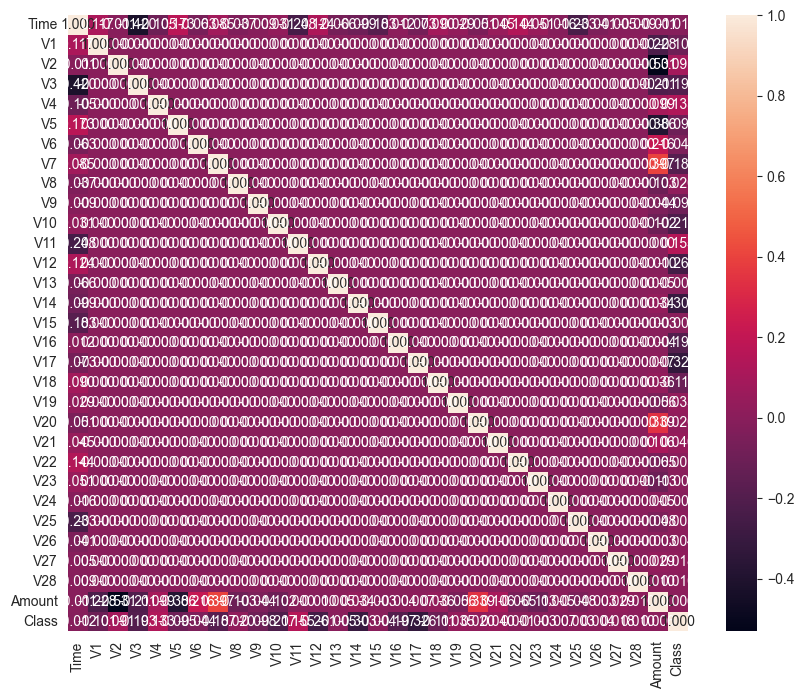

In [42]:
columns = df.select_dtypes(include = ['int', 'float'])
plt.figure(figsize = (10,8))
sns.heatmap(columns.corr(), annot=True, fmt='.3f')
plt.show()

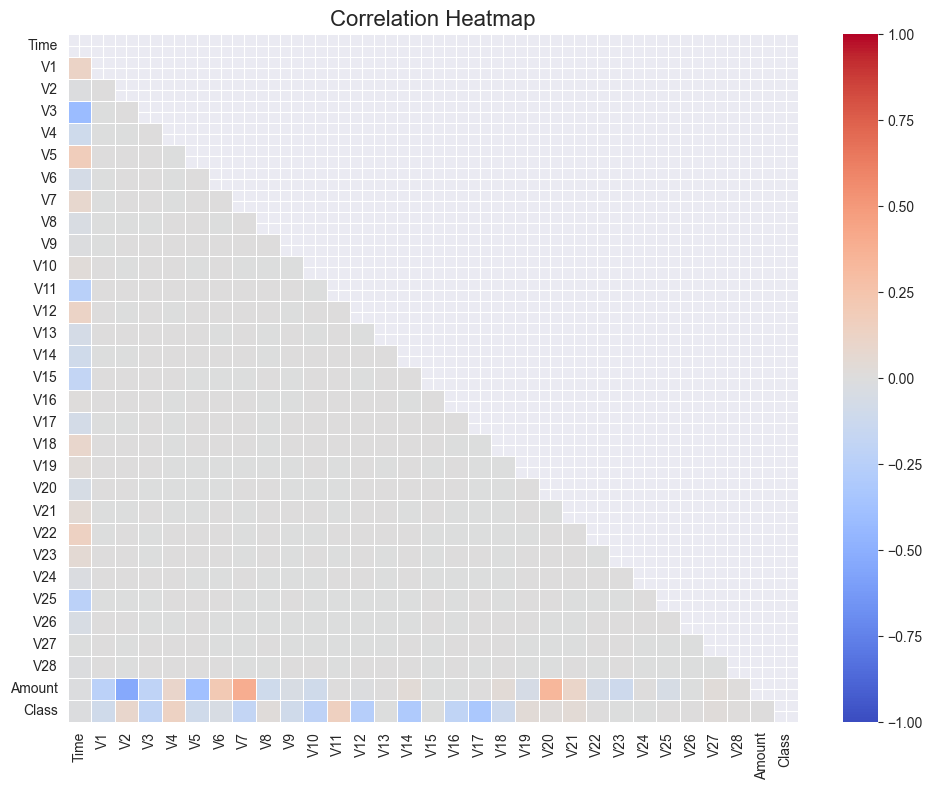


Top 10 Features Correlated with Class:
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64


In [30]:
# Корреляционная матрица признаков
plt.figure(figsize=(10, 8))
correlation = df.corr()
mask = np.triu(correlation)
sns.heatmap(correlation, annot=False, cmap='coolwarm', mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# Топ 10 признаков, коррелирующих с классом
class_corr = correlation['Class'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Class:")
print(class_corr[1:11])  # Exclude Class itself

In [47]:
X = df.drop('Class', axis=1)
y = df['Class']

In [49]:
X['Amount'].head

<bound method NDFrame.head of 0         149.62
1           2.69
2         378.66
3         123.50
4          69.99
           ...  
284802      0.77
284803     24.79
284804     67.88
284805     10.00
284806    217.00
Name: Amount, Length: 284807, dtype: float64>

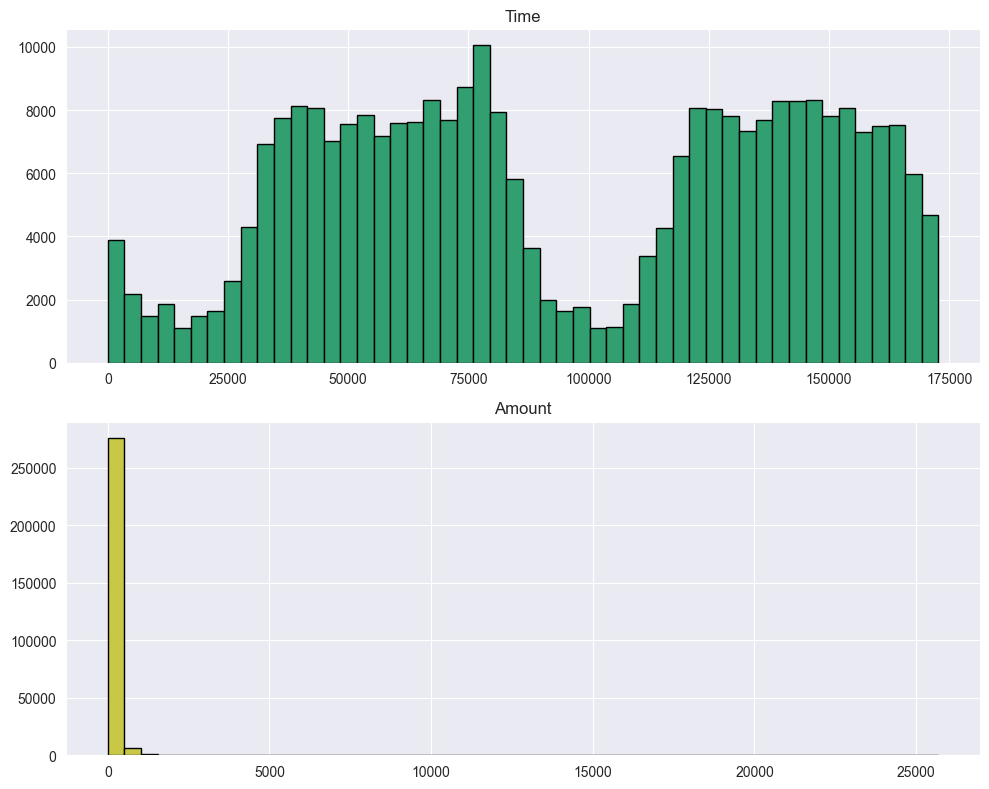

In [54]:
time_amount_columns = ['Time', 'Amount']
time_amount = df[time_amount_columns]


plt.figure(figsize=(10, 8))

np.random.seed(seed)
for idx, numeric in enumerate(time_amount_columns) :
    col = (np.random.random(), np.random.random(), np.random.random())

    plt.subplot(2, 1, idx+1)
    plt.hist(time_amount[numeric], bins=50, color=col, edgecolor='black')
    plt.title(numeric)
    plt.tight_layout()

plt.tight_layout()
plt.show()